In [ ]:
!pip install -q datasets transformers librosa soundfile torchaudio

In [ ]:
from datasets import load_dataset
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
from datasets import load_dataset

ds = load_dataset("JacobLinCool/VoiceBank-DEMAND-16k")

README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  444MB            

data/train-00000-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  416MB            

data/train-00001-of-00005.parquet: downloading bytes:           |  0.00B            

...

data/train-00004-of-00005.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  132MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/11572 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/824 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'clean', 'noisy'],
        num_rows: 11572
    })
    test: Dataset({
        features: ['id', 'clean', 'noisy'],
        num_rows: 824
    })
})


In [ ]:
print(ds["train"].features)

{'id': Value('string'), 'clean': Audio(sampling_rate=16000, decode=True, stream_index=None), 'noisy': Audio(sampling_rate=16000, decode=True, stream_index=None)}


In [ ]:
sample=ds["train"][0]
print(sample.keys())

dict_keys(['id', 'clean', 'noisy'])


In [ ]:
clean_audio=sample["clean"]["array"]
clean_sr=sample["clean"]["sampling_rate"]

noisy_audio=sample["noisy"]["array"]
noisy_sr=sample["noisy"]["sampling_rate"]

print(clean_audio.shape)
print(noisy_audio.shape)
print(clean_sr)

(36480,)
(36480,)
16000


In [ ]:
from IPython.display import Audio
print("Noisy")
Audio(noisy_audio,rate=noisy_sr)

Noisy


In [ ]:
print("Clean")
Audio(clean_audio,rate=clean_sr)

Clean


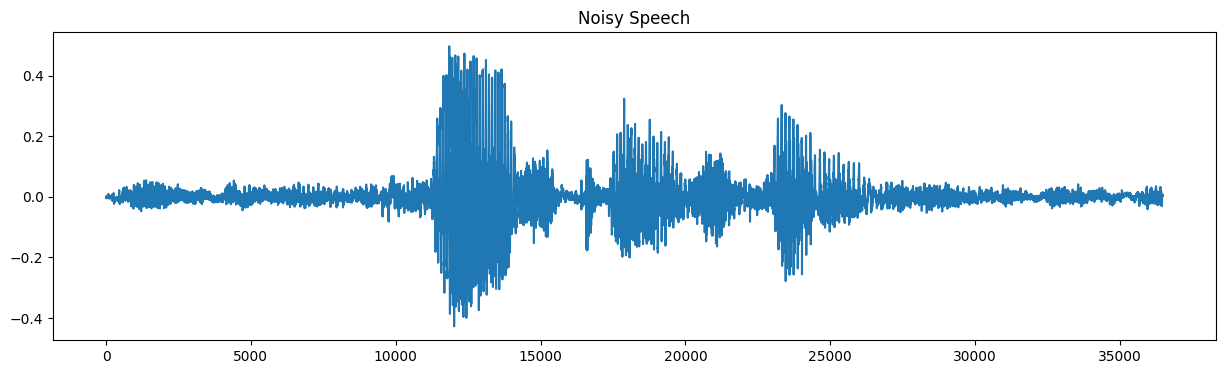

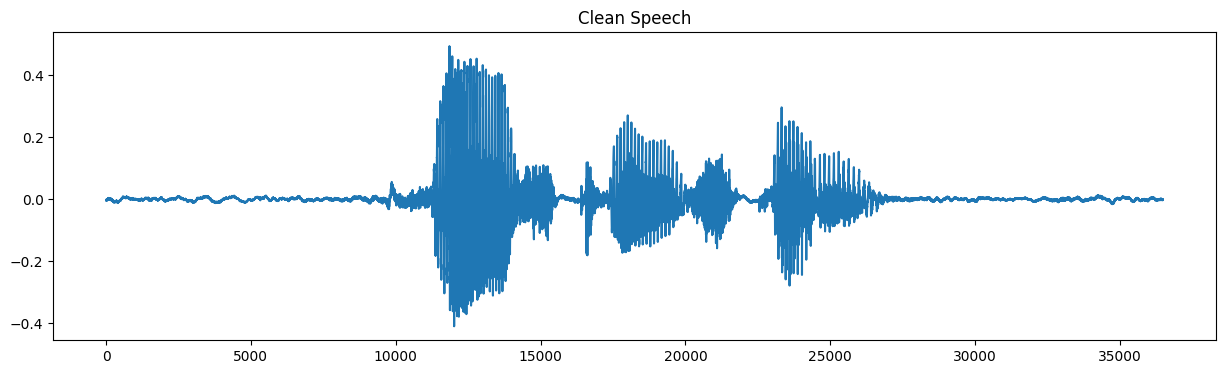

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(noisy_audio)
plt.title("Noisy Speech")
plt.show()

plt.figure(figsize=(15,4))
plt.plot(clean_audio)
plt.title("Clean Speech")
plt.show()

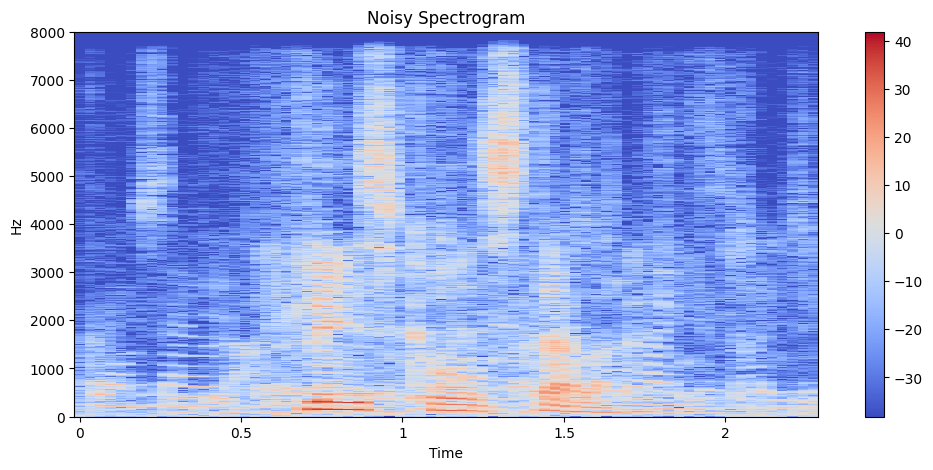

In [ ]:
spec = librosa.stft(noisy_audio)
spec_db=librosa.amplitude_to_db(np.abs(spec))

plt.figure(figsize=(12,5))
librosa.display.specshow(
    spec_db,
    sr=noisy_sr,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar()
plt.title("Noisy Spectrogram")
plt.show()

In [ ]:
import librosa.display

In [ ]:
from torch.utils.data import Dataset

class VoiceBankDataset(Dataset):

    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        sample = self.dataset[idx]

        noisy = sample["noisy"]["array"]
        clean = sample["clean"]["array"]

        noisy = torch.tensor(noisy, dtype=torch.float32)
        clean = torch.tensor(clean, dtype=torch.float32)

        return noisy, clean

In [ ]:
train_dataset = VoiceBankDataset(ds["train"])
test_dataset = VoiceBankDataset(ds["test"])

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)